In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import yfinance as yf

In [4]:
df = pd.read_csv("../financial_data/vinfast_stock_data.csv")

In [5]:
df

,Date,Open,High,Low,CloseClosing price adjusted for splits.,Adj CloseAdjusted closing price adjusted for splits and dividend and/or capital gain distributions.,Volume
0,27 Apr 2026,4.24,4.340,4.1566,4.215,4.215,443575
1,24 Apr 2026,4.41,4.450,4.3350,4.360,4.360,457200
2,23 Apr 2026,4.57,4.605,4.1400,4.410,4.410,1333100
3,22 Apr 2026,4.88,5.120,4.5800,4.690,4.690,1409000
4,21 Apr 2026,4.41,5.285,4.3750,4.760,4.760,5725900
...,...,...,...,...,...,...,...
1159,13 Sept 2021,9.71,9.710,9.7100,9.710,9.710,400
1160,10 Sept 2021,9.69,9.690,9.6800,9.680,9.680,700
1161,9 Sept 2021,9.61,9.691,9.6100,9.682,9.682,400
1162,8 Sept 2021,9.71,9.710,9.7100,9.710,9.710,3700


In [6]:
df.columns = ['date', 'open', 'high', 'low', 'adjusted_close_for_splits', 'adjusted_close_for_splits_dividend_capital_gain', 'volume']

In [7]:
df.shape

(1164, 7)

In [8]:
df.isna().sum()

date                                               0
open                                               0
high                                               0
low                                                0
adjusted_close_for_splits                          0
adjusted_close_for_splits_dividend_capital_gain    0
volume                                             0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [20]:
df['date'] = pd.to_datetime(df['date'], format="mixed")


In [26]:
df = df.sort_values(['date'],ascending=True) 
df


,level_0,index,date,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume
0,0,1163,2021-09-07,9.93,9.980,9.7970,9.797,9.797,3700
1,1,1162,2021-09-08,9.71,9.710,9.7100,9.710,9.710,3700
2,2,1161,2021-09-09,9.61,9.691,9.6100,9.682,9.682,400
3,3,1160,2021-09-10,9.69,9.690,9.6800,9.680,9.680,700
4,4,1159,2021-09-13,9.71,9.710,9.7100,9.710,9.710,400
...,...,...,...,...,...,...,...,...,...
1159,1159,4,2026-04-21,4.41,5.285,4.3750,4.760,4.760,5725900
1160,1160,3,2026-04-22,4.88,5.120,4.5800,4.690,4.690,1409000
1161,1161,2,2026-04-23,4.57,4.605,4.1400,4.410,4.410,1333100
1162,1162,1,2026-04-24,4.41,4.450,4.3350,4.360,4.360,457200


In [27]:
df.drop(['level_0', 'index'],axis=1,inplace=True) 
df

,date,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume
0,2021-09-07,9.93,9.980,9.7970,9.797,9.797,3700
1,2021-09-08,9.71,9.710,9.7100,9.710,9.710,3700
2,2021-09-09,9.61,9.691,9.6100,9.682,9.682,400
3,2021-09-10,9.69,9.690,9.6800,9.680,9.680,700
4,2021-09-13,9.71,9.710,9.7100,9.710,9.710,400
...,...,...,...,...,...,...,...
1159,2026-04-21,4.41,5.285,4.3750,4.760,4.760,5725900
1160,2026-04-22,4.88,5.120,4.5800,4.690,4.690,1409000
1161,2026-04-23,4.57,4.605,4.1400,4.410,4.410,1333100
1162,2026-04-24,4.41,4.450,4.3350,4.360,4.360,457200


In [28]:
df.corr(numeric_only=True)

,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain
open,1.000000,0.977752,0.981942,0.966705,0.966705
high,0.977752,1.000000,0.964275,0.985585,0.985585
low,0.981942,0.964275,1.000000,0.982136,0.982136
adjusted_close_for_splits,0.966705,0.985585,0.982136,1.000000,1.000000
adjusted_close_for_splits_dividend_capital_gain,0.966705,0.985585,0.982136,1.000000,1.000000


In [31]:
plt.style.use("bmh")

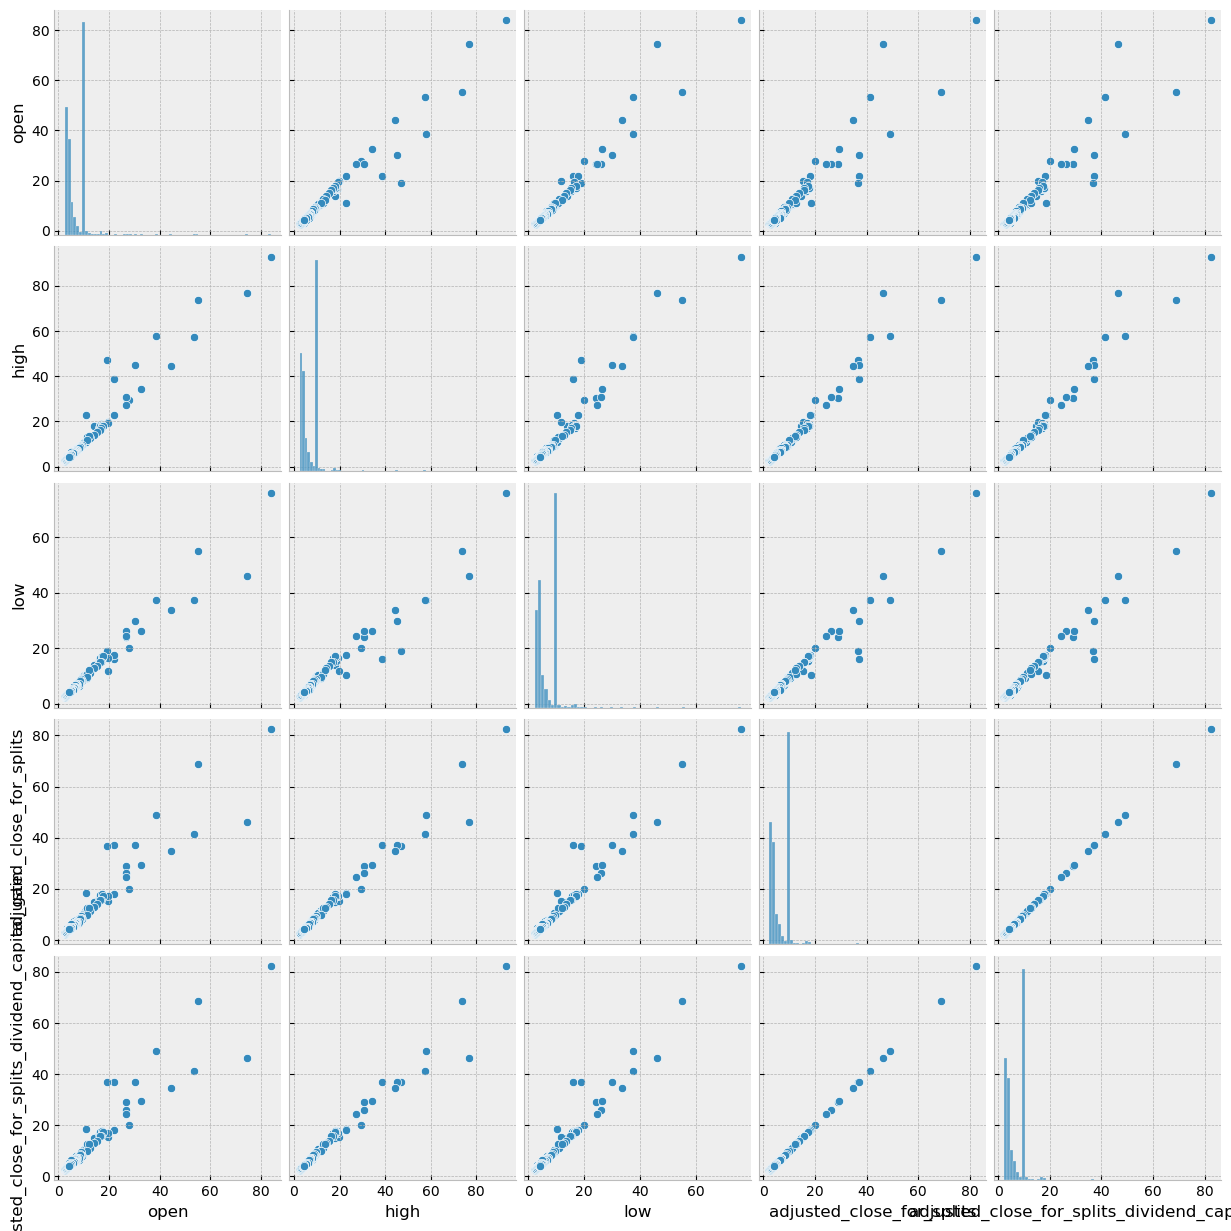

In [32]:
sns.pairplot(df)

In [33]:
df.index = df.date 
df.drop(['date'],axis=1,inplace=True) 


In [35]:
df

,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume
date,,,,,,
2021-09-07,9.93,9.980,9.7970,9.797,9.797,3700
2021-09-08,9.71,9.710,9.7100,9.710,9.710,3700
2021-09-09,9.61,9.691,9.6100,9.682,9.682,400
2021-09-10,9.69,9.690,9.6800,9.680,9.680,700
2021-09-13,9.71,9.710,9.7100,9.710,9.710,400
...,...,...,...,...,...,...
2026-04-21,4.41,5.285,4.3750,4.760,4.760,5725900
2026-04-22,4.88,5.120,4.5800,4.690,4.690,1409000
2026-04-23,4.57,4.605,4.1400,4.410,4.410,1333100


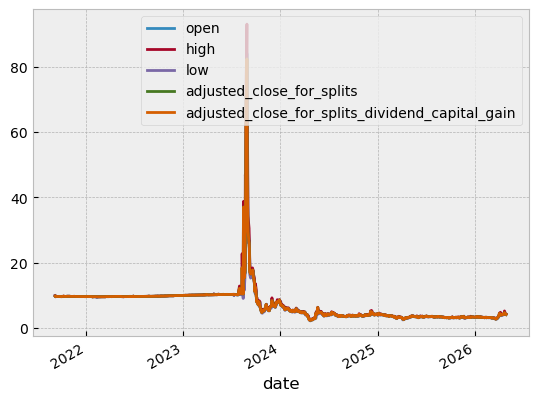

In [42]:
plt.Figure(figsize=(10,10))
df.plot(kind='line')

plt.show()

In [44]:
lagged_volume = df['volume'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

df['lagged_volume'] = lagged_volume 

# lagged adjusted close
lagged_adjusted_close = df['adjusted_close_for_splits'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
df['lagged_adjusted_close_for_splits'] = lagged_adjusted_close


lagged_adjusted_close = df['adjusted_close_for_splits_dividend_capital_gain'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
df['adjusted_close_for_splits_dividend_capital_gain'] = lagged_adjusted_close



# lagged adjusted high
lagged_high = df['high'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
df['lagged_high'] = lagged_high 

# lagged low 
lagged_low = df['low'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
df['lagged_low'] = lagged_low 

df.head()









,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume,lagged_volume,lagged_adjusted_close_for_splits,lagged_high,lagged_low
date,,,,,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,0.000,3700,0,0.000,0.000,0.000
2021-09-08,9.71,9.710,9.710,9.710,9.797,3700,3700,9.797,9.980,9.797
2021-09-09,9.61,9.691,9.610,9.682,9.710,400,3700,9.710,9.710,9.710
2021-09-10,9.69,9.690,9.680,9.680,9.682,700,400,9.682,9.691,9.610
2021-09-13,9.71,9.710,9.710,9.710,9.680,400,700,9.680,9.690,9.680


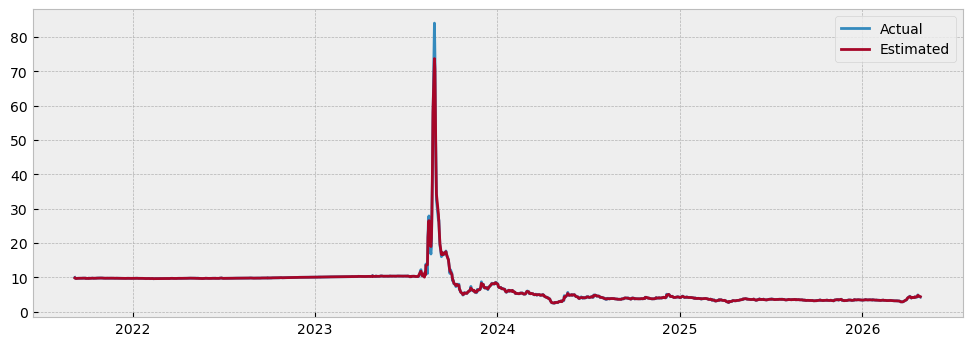

In [108]:
from statsmodels.tsa.seasonal import STL
open_price = pd.DataFrame(df[['open']])


stl = STL(open_price['open'], period=2) 
result = stl.fit()
seasonal, trend, resid = result.seasonal, result.trend, result.resid 


estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price.index, open_price.open) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

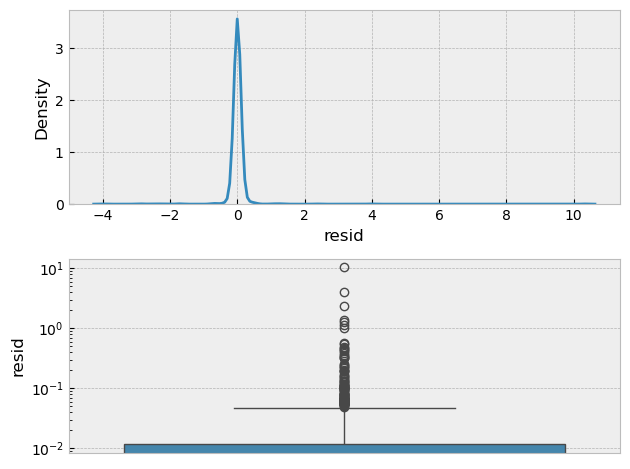

Shapiro -> ShapiroResult(statistic=0.16166572926210387, pvalue=1.0582225252135956e-57)


In [104]:
fig, axes=plt.subplots(2) 

sns.kdeplot(resid, ax=axes[0])
sns.boxplot(resid, ax=axes[1])
axes[1].set_yscale("log") 
plt.tight_layout()
plt.show()

import scipy.stats as stats 


print (f"Shapiro -> {stats.shapiro(resid)}")

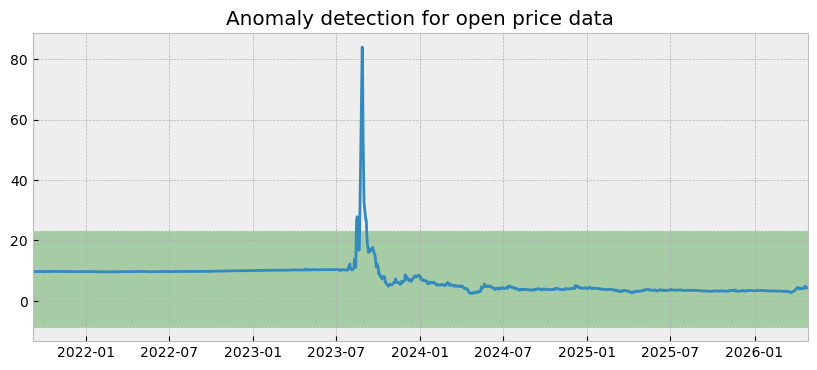

In [51]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['open'].mean() 
open_dev = df['open'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.open) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for open price data")
plt.show()

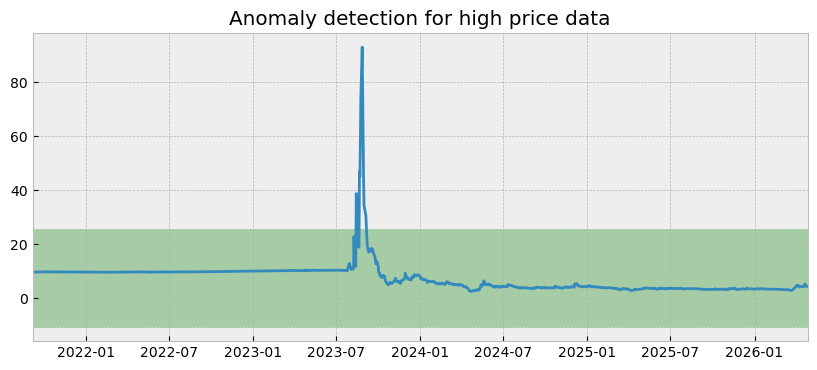

In [53]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['high'].mean() 
open_dev = df['high'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data")
plt.show()

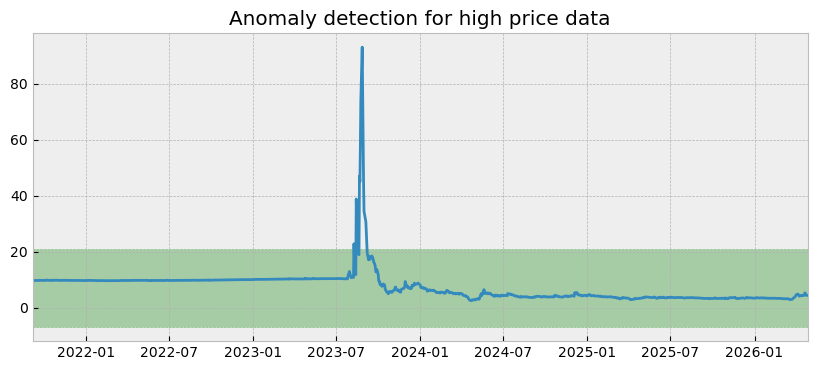

In [72]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['low'].mean() 
open_dev = df['low'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data")
plt.show()

In [91]:
df.volume = df.volume.str.replace("-", "0")
df.volume = pd.to_numeric(df.volume)

In [89]:
df.iloc[5]

open                                                       9.71
high                                                       9.71
low                                                        9.71
adjusted_close_for_splits                                  9.71
adjusted_close_for_splits_dividend_capital_gain            9.71
volume                                                        -
open_imputed                                               9.71
high_imputed                                               9.71
low_imputed                                                9.71
adjusted_close_for_splits_imputed                          9.71
adjusted_close_for_splits_dividend_capital_gain_imputed    9.71
Name: 2021-09-14 00:00:00, dtype: object

In [109]:


# replacing the anomalies




def impute_median(column): 
    print (f"Computing for column: {column}")
    median = df[column].median() 
    print (f"median: {median}")
    std = df[column].std() 
    print (f"std: {std}")
    mean = df[column].mean() 
    print (f"mean: {mean}")
    # calculating the upper limit




    upper = np.percentile(df[column], 75)
    lower=np.percentile(df[column], 25)
    print (f"upper: {upper}")
    print (f"lower: {lower}")
    # checking if the value is above or below 
    print ("Imputing...")

    values = [median if value > upper or value < lower else value for value in df[column]]
    print ("Done") 
    print ("----------------------")
    return values 


for a in df.columns:
    print (f"Column -> {a}")
    df[f"{a}_imputed"] = impute_median(a)


Column -> open
Computing for column: open
median: 6.07
std: 5.298267718364858
mean: 7.206317869415808
upper: 9.75
lower: 3.64
Imputing...
Done
----------------------
Column -> high
Computing for column: high
median: 6.217499999999999
std: 6.042286284452237
mean: 7.409602233676974
upper: 9.76
lower: 3.74
Imputing...
Done
----------------------
Column -> low
Computing for column: low
median: 5.79
std: 4.665298893987975
mean: 7.0261843642611685
upper: 9.75
lower: 3.55875
Imputing...
Done
----------------------
Column -> adjusted_close_for_splits
Computing for column: adjusted_close_for_splits
median: 5.995
std: 5.186904830859797
mean: 7.198679553264604
upper: 9.75
lower: 3.62
Imputing...
Done
----------------------
Column -> adjusted_close_for_splits_dividend_capital_gain
Computing for column: adjusted_close_for_splits_dividend_capital_gain
median: 5.995
std: 5.190459709064814
mean: 7.195058419243986
upper: 9.75
lower: 3.6175
Imputing...
Done
----------------------
Column -> volume
Comput

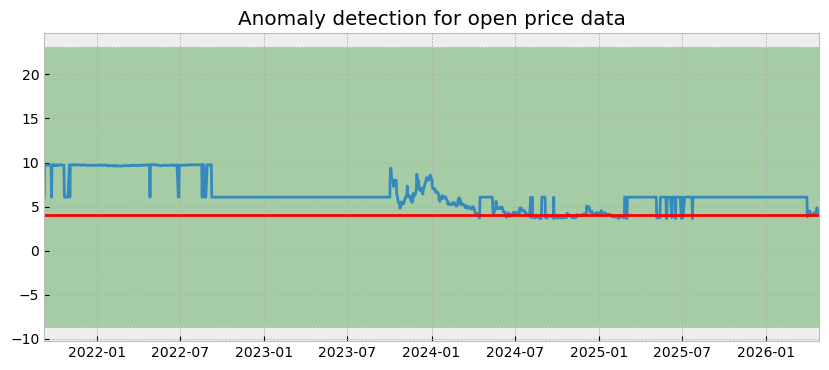

In [117]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['open'].mean() 
open_dev = df['open'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.open_imputed) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))

plt.axhline(y=4, color='r')
plt.title("Anomaly detection for open price data")
plt.show()

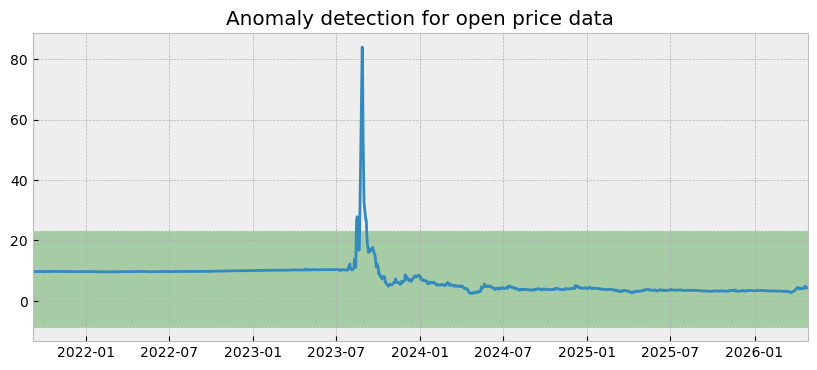

In [114]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['open'].mean() 
open_dev = df['open'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.open) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for open price data")
plt.show()

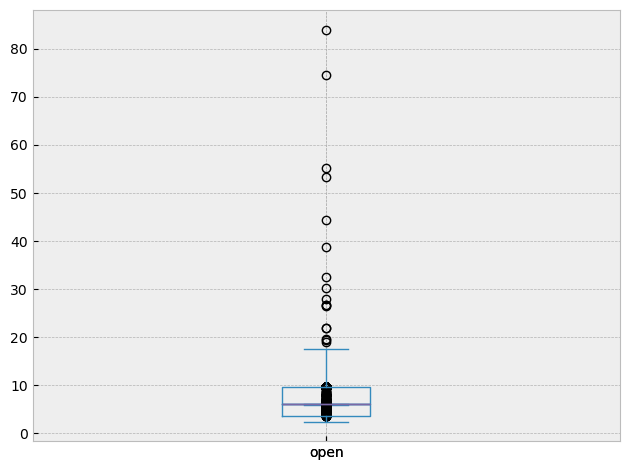

In [113]:
df['open_imputed'].plot(kind='box')
df['open'].plot(kind='box')
plt.tight_layout()

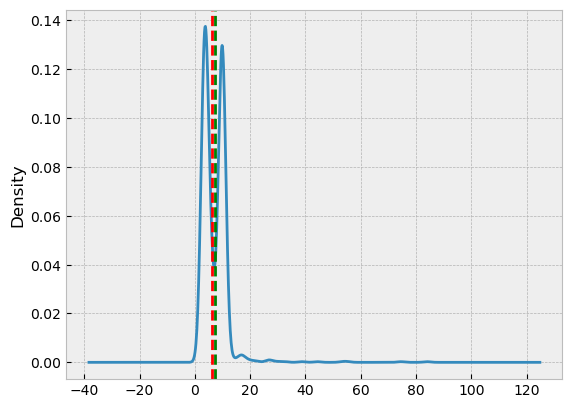

In [68]:

plt.ylabel("Open Price $")

df['open'].plot(kind='kde')
plt.axvline(x=df['open'].median(), color='r', linestyle='--')
plt.axvline(x=df['open'].mean(), color='g', linestyle='--')
plt.show()

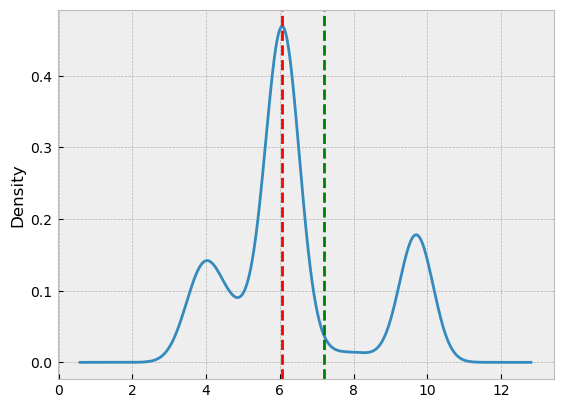

In [118]:

plt.ylabel("Open Price $ imputed")

df['open_imputed'].plot(kind='kde')
plt.axvline(x=df['open'].median(), color='r', linestyle='--')
plt.axvline(x=df['open'].mean(), color='g', linestyle='--')
plt.show()

In [120]:
df

,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume,open_imputed,high_imputed,low_imputed,adjusted_close_for_splits_imputed,...,high_imputed_imputed,low_imputed_imputed,adjusted_close_for_splits_imputed_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed_imputed,volume_imputed_imputed,open_imputed_imputed_imputed,high_imputed_imputed_imputed,low_imputed_imputed_imputed,adjusted_close_for_splits_imputed_imputed_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed_imputed_imputed
date,,,,,,,,,,,,,,,,,,,,,
2021-09-07,9.93,9.980,9.7970,9.797,0.000,3700,6.07,6.2175,5.7900,5.995,...,6.2175,5.79,5.995,5.995,359650.0,6.07,6.2175,5.79,5.995,5.995
2021-09-08,9.71,9.710,9.7100,9.710,9.797,3700,9.71,9.7100,9.7100,9.710,...,6.2175,5.79,5.995,5.995,359650.0,6.07,6.2175,5.79,5.995,5.995
2021-09-09,9.61,9.691,9.6100,9.682,9.710,400,9.61,9.6910,9.6100,9.682,...,6.2175,5.79,5.995,5.995,359650.0,6.07,6.2175,5.79,5.995,5.995
2021-09-10,9.69,9.690,9.6800,9.680,9.682,700,9.69,9.6900,9.6800,9.680,...,6.2175,5.79,5.995,5.995,359650.0,6.07,6.2175,5.79,5.995,5.995
2021-09-13,9.71,9.710,9.7100,9.710,9.680,400,9.71,9.7100,9.7100,9.710,...,6.2175,5.79,5.995,5.995,359650.0,6.07,6.2175,5.79,5.995,5.995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-21,4.41,5.285,4.3750,4.760,4.350,5725900,4.41,5.2850,4.3750,4.760,...,6.2175,5.79,5.995,5.995,359650.0,6.07,6.2175,5.79,5.995,5.995
2026-04-22,4.88,5.120,4.5800,4.690,4.760,1409000,4.88,5.1200,4.5800,4.690,...,6.2175,5.79,5.995,5.995,359650.0,6.07,6.2175,5.79,5.995,5.995
2026-04-23,4.57,4.605,4.1400,4.410,4.690,1333100,4.57,4.6050,4.1400,4.410,...,6.2175,5.79,5.995,5.995,359650.0,6.07,6.2175,5.79,5.995,5.995


In [121]:
lagged_volume = df['volume_imputed'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

df['lagged_volume'] = lagged_volume 

# lagged adjusted close
lagged_adjusted_close = df['adjusted_close_for_splits_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
df['lagged_adjusted_close_for_splits'] = lagged_adjusted_close


lagged_adjusted_close = df['adjusted_close_for_splits_dividend_capital_gain_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
df['lagged_adjusted_close_for_splits_dividend_capital_gain'] = lagged_adjusted_close



# lagged adjusted high
lagged_high = df['high_imputed'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
df['lagged_high'] = lagged_high 

# lagged low 
lagged_low = df['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
df['lagged_low'] = lagged_low 

df.head()









,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume,open_imputed,high_imputed,low_imputed,adjusted_close_for_splits_imputed,...,open_imputed_imputed_imputed,high_imputed_imputed_imputed,low_imputed_imputed_imputed,adjusted_close_for_splits_imputed_imputed_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed_imputed_imputed,lagged_volume,lagged_adjusted_close_for_splits,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low
date,,,,,,,,,,,,,,,,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,0.000,3700,6.07,6.2175,5.79,5.995,...,6.07,6.2175,5.79,5.995,5.995,0.0,0.000,0.000,0.0000,0.00
2021-09-08,9.71,9.710,9.710,9.710,9.797,3700,9.71,9.7100,9.71,9.710,...,6.07,6.2175,5.79,5.995,5.995,359650.0,5.995,5.995,6.2175,5.79
2021-09-09,9.61,9.691,9.610,9.682,9.710,400,9.61,9.6910,9.61,9.682,...,6.07,6.2175,5.79,5.995,5.995,359650.0,9.710,5.995,9.7100,9.71
2021-09-10,9.69,9.690,9.680,9.680,9.682,700,9.69,9.6900,9.68,9.680,...,6.07,6.2175,5.79,5.995,5.995,359650.0,9.682,9.710,9.6910,9.61
2021-09-13,9.71,9.710,9.710,9.710,9.680,400,9.71,9.7100,9.71,9.710,...,6.07,6.2175,5.79,5.995,5.995,359650.0,9.680,9.682,9.6900,9.68


In [122]:
df

,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume,open_imputed,high_imputed,low_imputed,adjusted_close_for_splits_imputed,...,open_imputed_imputed_imputed,high_imputed_imputed_imputed,low_imputed_imputed_imputed,adjusted_close_for_splits_imputed_imputed_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed_imputed_imputed,lagged_volume,lagged_adjusted_close_for_splits,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low
date,,,,,,,,,,,,,,,,,,,,,
2021-09-07,9.93,9.980,9.7970,9.797,0.000,3700,6.07,6.2175,5.7900,5.995,...,6.07,6.2175,5.79,5.995,5.995,0.0,0.000,0.000,0.0000,0.000
2021-09-08,9.71,9.710,9.7100,9.710,9.797,3700,9.71,9.7100,9.7100,9.710,...,6.07,6.2175,5.79,5.995,5.995,359650.0,5.995,5.995,6.2175,5.790
2021-09-09,9.61,9.691,9.6100,9.682,9.710,400,9.61,9.6910,9.6100,9.682,...,6.07,6.2175,5.79,5.995,5.995,359650.0,9.710,5.995,9.7100,9.710
2021-09-10,9.69,9.690,9.6800,9.680,9.682,700,9.69,9.6900,9.6800,9.680,...,6.07,6.2175,5.79,5.995,5.995,359650.0,9.682,9.710,9.6910,9.610
2021-09-13,9.71,9.710,9.7100,9.710,9.680,400,9.71,9.7100,9.7100,9.710,...,6.07,6.2175,5.79,5.995,5.995,359650.0,9.680,9.682,9.6900,9.680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-21,4.41,5.285,4.3750,4.760,4.350,5725900,4.41,5.2850,4.3750,4.760,...,6.07,6.2175,5.79,5.995,5.995,801300.0,4.350,4.210,4.4000,4.190
2026-04-22,4.88,5.120,4.5800,4.690,4.760,1409000,4.88,5.1200,4.5800,4.690,...,6.07,6.2175,5.79,5.995,5.995,359650.0,4.760,4.350,5.2850,4.375
2026-04-23,4.57,4.605,4.1400,4.410,4.690,1333100,4.57,4.6050,4.1400,4.410,...,6.07,6.2175,5.79,5.995,5.995,359650.0,4.690,4.760,5.1200,4.580


# Building the model

In [123]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor


In [124]:
df.shape

(1164, 28)

In [127]:
1164 * 0.8

931.2

In [128]:
df.columns

Index(['open', 'high', 'low', 'adjusted_close_for_splits',
       'adjusted_close_for_splits_dividend_capital_gain', 'volume',
       'open_imputed', 'high_imputed', 'low_imputed',
       'adjusted_close_for_splits_imputed',
       'adjusted_close_for_splits_dividend_capital_gain_imputed',
       'volume_imputed', 'open_imputed_imputed', 'high_imputed_imputed',
       'low_imputed_imputed', 'adjusted_close_for_splits_imputed_imputed',
       'adjusted_close_for_splits_dividend_capital_gain_imputed_imputed',
       'volume_imputed_imputed', 'open_imputed_imputed_imputed',
       'high_imputed_imputed_imputed', 'low_imputed_imputed_imputed',
       'adjusted_close_for_splits_imputed_imputed_imputed',
       'adjusted_close_for_splits_dividend_capital_gain_imputed_imputed_imputed',
       'lagged_volume', 'lagged_adjusted_close_for_splits',
       'lagged_adjusted_close_for_splits_dividend_capital_gain', 'lagged_high',
       'lagged_low'],
      dtype='object')

In [ ]:
df 

,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume,open_imputed,high_imputed,low_imputed,adjusted_close_for_splits_imputed,...,open_imputed_imputed_imputed,high_imputed_imputed_imputed,low_imputed_imputed_imputed,adjusted_close_for_splits_imputed_imputed_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed_imputed_imputed,lagged_volume,lagged_adjusted_close_for_splits,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low
date,,,,,,,,,,,,,,,,,,,,,
2021-09-07,9.93,9.980,9.7970,9.797,0.000,3700,6.07,6.2175,5.7900,5.995,...,6.07,6.2175,5.79,5.995,5.995,0.0,0.000,0.000,0.0000,0.000
2021-09-08,9.71,9.710,9.7100,9.710,9.797,3700,9.71,9.7100,9.7100,9.710,...,6.07,6.2175,5.79,5.995,5.995,359650.0,5.995,5.995,6.2175,5.790
2021-09-09,9.61,9.691,9.6100,9.682,9.710,400,9.61,9.6910,9.6100,9.682,...,6.07,6.2175,5.79,5.995,5.995,359650.0,9.710,5.995,9.7100,9.710
2021-09-10,9.69,9.690,9.6800,9.680,9.682,700,9.69,9.6900,9.6800,9.680,...,6.07,6.2175,5.79,5.995,5.995,359650.0,9.682,9.710,9.6910,9.610
2021-09-13,9.71,9.710,9.7100,9.710,9.680,400,9.71,9.7100,9.7100,9.710,...,6.07,6.2175,5.79,5.995,5.995,359650.0,9.680,9.682,9.6900,9.680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-21,4.41,5.285,4.3750,4.760,4.350,5725900,4.41,5.2850,4.3750,4.760,...,6.07,6.2175,5.79,5.995,5.995,801300.0,4.350,4.210,4.4000,4.190
2026-04-22,4.88,5.120,4.5800,4.690,4.760,1409000,4.88,5.1200,4.5800,4.690,...,6.07,6.2175,5.79,5.995,5.995,359650.0,4.760,4.350,5.2850,4.375
2026-04-23,4.57,4.605,4.1400,4.410,4.690,1333100,4.57,4.6050,4.1400,4.410,...,6.07,6.2175,5.79,5.995,5.995,359650.0,4.690,4.760,5.1200,4.580


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1164 entries, 0 to 1163
Data columns (total 29 columns):
 #   Column                                                                   Non-Null Count  Dtype         
---  ------                                                                   --------------  -----         
 0   date                                                                     1164 non-null   datetime64[ns]
 1   open                                                                     1164 non-null   float64       
 2   high                                                                     1164 non-null   float64       
 3   low                                                                      1164 non-null   float64       
 4   adjusted_close_for_splits                                                1164 non-null   float64       
 5   adjusted_close_for_splits_dividend_capital_gain                          1164 non-null   float64       
 6   volume          

In [131]:
df.reset_index(inplace=True)

In [ ]:
df['date'] = pd.to_datetime(df['date'])
filtered_df = df.iloc[1:]

In [156]:
filtered_df['day'] = filtered_df['date'].dt.day 
filtered_df['month'] = filtered_df['date'].dt.month 
filtered_df['year'] = filtered_df['date'].dt.year

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/2412971178.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['day'] = filtered_df['date'].dt.day
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/2412971178.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['month'] = filtered_df['date'].dt.month
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/2412971178.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [157]:
filtered_df

,date,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume,open_imputed,high_imputed,low_imputed,...,adjusted_close_for_splits_imputed_imputed_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed_imputed_imputed,lagged_volume,lagged_adjusted_close_for_splits,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low,day,month,year
1,2021-09-08,9.71,9.710,9.7100,9.710,9.797,3700,9.71,9.710,9.7100,...,5.995,5.995,359650.0,5.995,5.995,6.2175,5.790,8,9,2021
2,2021-09-09,9.61,9.691,9.6100,9.682,9.710,400,9.61,9.691,9.6100,...,5.995,5.995,359650.0,9.710,5.995,9.7100,9.710,9,9,2021
3,2021-09-10,9.69,9.690,9.6800,9.680,9.682,700,9.69,9.690,9.6800,...,5.995,5.995,359650.0,9.682,9.710,9.6910,9.610,10,9,2021
4,2021-09-13,9.71,9.710,9.7100,9.710,9.680,400,9.71,9.710,9.7100,...,5.995,5.995,359650.0,9.680,9.682,9.6900,9.680,13,9,2021
5,2021-09-14,9.71,9.710,9.7100,9.710,9.710,0,9.71,9.710,9.7100,...,5.995,5.995,359650.0,9.710,9.680,9.7100,9.710,14,9,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,2026-04-21,4.41,5.285,4.3750,4.760,4.350,5725900,4.41,5.285,4.3750,...,5.995,5.995,801300.0,4.350,4.210,4.4000,4.190,21,4,2026
1160,2026-04-22,4.88,5.120,4.5800,4.690,4.760,1409000,4.88,5.120,4.5800,...,5.995,5.995,359650.0,4.760,4.350,5.2850,4.375,22,4,2026
1161,2026-04-23,4.57,4.605,4.1400,4.410,4.690,1333100,4.57,4.605,4.1400,...,5.995,5.995,359650.0,4.690,4.760,5.1200,4.580,23,4,2026
1162,2026-04-24,4.41,4.450,4.3350,4.360,4.410,457200,4.41,4.450,4.3350,...,5.995,5.995,359650.0,4.410,4.690,4.6050,4.140,24,4,2026


In [177]:
filtered_df

,date,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume,open_imputed,high_imputed,low_imputed,...,adjusted_close_for_splits_imputed_imputed_imputed,adjusted_close_for_splits_dividend_capital_gain_imputed_imputed_imputed,lagged_volume,lagged_adjusted_close_for_splits,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low,day,month,year
1,2021-09-08,9.71,9.710,9.7100,9.710,9.797,3700,9.71,9.710,9.7100,...,5.995,5.995,359650.0,5.995,5.995,6.2175,5.790,8,9,2021
2,2021-09-09,9.61,9.691,9.6100,9.682,9.710,400,9.61,9.691,9.6100,...,5.995,5.995,359650.0,9.710,5.995,9.7100,9.710,9,9,2021
3,2021-09-10,9.69,9.690,9.6800,9.680,9.682,700,9.69,9.690,9.6800,...,5.995,5.995,359650.0,9.682,9.710,9.6910,9.610,10,9,2021
4,2021-09-13,9.71,9.710,9.7100,9.710,9.680,400,9.71,9.710,9.7100,...,5.995,5.995,359650.0,9.680,9.682,9.6900,9.680,13,9,2021
5,2021-09-14,9.71,9.710,9.7100,9.710,9.710,0,9.71,9.710,9.7100,...,5.995,5.995,359650.0,9.710,9.680,9.7100,9.710,14,9,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,2026-04-21,4.41,5.285,4.3750,4.760,4.350,5725900,4.41,5.285,4.3750,...,5.995,5.995,801300.0,4.350,4.210,4.4000,4.190,21,4,2026
1160,2026-04-22,4.88,5.120,4.5800,4.690,4.760,1409000,4.88,5.120,4.5800,...,5.995,5.995,359650.0,4.760,4.350,5.2850,4.375,22,4,2026
1161,2026-04-23,4.57,4.605,4.1400,4.410,4.690,1333100,4.57,4.605,4.1400,...,5.995,5.995,359650.0,4.690,4.760,5.1200,4.580,23,4,2026
1162,2026-04-24,4.41,4.450,4.3350,4.360,4.410,457200,4.41,4.450,4.3350,...,5.995,5.995,359650.0,4.410,4.690,4.6050,4.140,24,4,2026


In [197]:
filtered_df = filtered_df.sort_values(['date'],ascending=True) 

X = filtered_df[['lagged_high','lagged_low', 'lagged_adjusted_close_for_splits_dividend_capital_gain', 'lagged_volume', 'day', 'month', 'year']]
y = filtered_df.open_imputed.values.reshape(-1,1)

X_train = X.head(931) 
X_test = X.tail(1163-931)

Y_train = y[0:931]
Y_test = y[931:1163]

In [198]:
X_train

,lagged_high,lagged_low,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_volume,day,month,year
1,6.2175,5.790,5.995,359650.0,8,9,2021
2,9.7100,9.710,5.995,359650.0,9,9,2021
3,9.6910,9.610,9.710,359650.0,10,9,2021
4,9.6900,9.680,9.682,359650.0,13,9,2021
5,9.7100,9.710,9.680,359650.0,14,9,2021
...,...,...,...,...,...,...,...
927,6.2175,5.790,3.620,310600.0,16,5,2025
928,6.2175,3.584,5.995,387700.0,19,5,2025
929,6.2175,5.790,5.995,400700.0,20,5,2025
930,6.2175,5.790,5.995,337200.0,21,5,2025


In [199]:
y

array([[9.71],
       [9.61],
       [9.69],
       ...,
       [4.57],
       [4.41],
       [4.24]])

In [200]:
X_train

,lagged_high,lagged_low,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_volume,day,month,year
1,6.2175,5.790,5.995,359650.0,8,9,2021
2,9.7100,9.710,5.995,359650.0,9,9,2021
3,9.6910,9.610,9.710,359650.0,10,9,2021
4,9.6900,9.680,9.682,359650.0,13,9,2021
5,9.7100,9.710,9.680,359650.0,14,9,2021
...,...,...,...,...,...,...,...
927,6.2175,5.790,3.620,310600.0,16,5,2025
928,6.2175,3.584,5.995,387700.0,19,5,2025
929,6.2175,5.790,5.995,400700.0,20,5,2025
930,6.2175,5.790,5.995,337200.0,21,5,2025


In [201]:
model = XGBRegressor() 

model.fit(X_train, Y_train)
pred = model.predict(X_test)

In [202]:
# metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [203]:
np.shape(Y_test)

(232, 1)

In [204]:
np.shape(X_test)

(232, 7)

In [205]:
print (root_mean_squared_error(y_pred=pred, y_true=Y_test))
print (mean_absolute_error(y_pred=pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=pred))

0.44657557012519977
0.133193923070513
0.48733987927282274


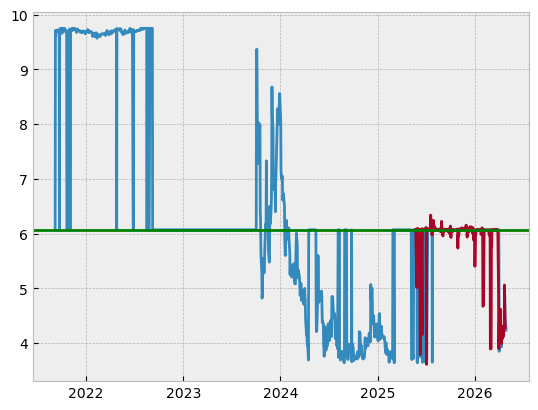

In [210]:
# plotting


plt.plot(df.date, df.open_imputed)
plt.plot(df.date.iloc[931:1163], pred)

plt.axhline(y=df['open'].median(), color='g')

Text(0.5, 0, 'Y test')

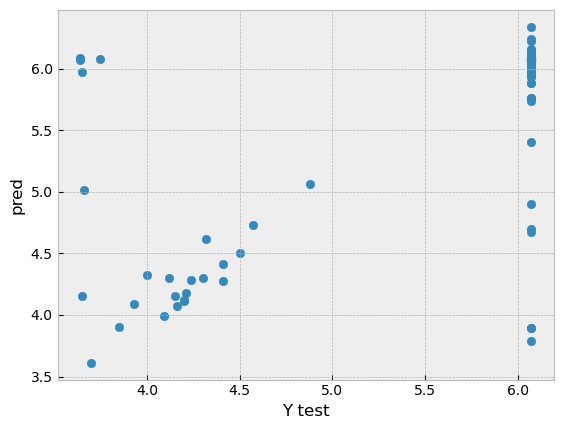

In [213]:
plt.scatter(Y_test, pred) 
plt.ylabel("pred") 
plt.xlabel("Y test")

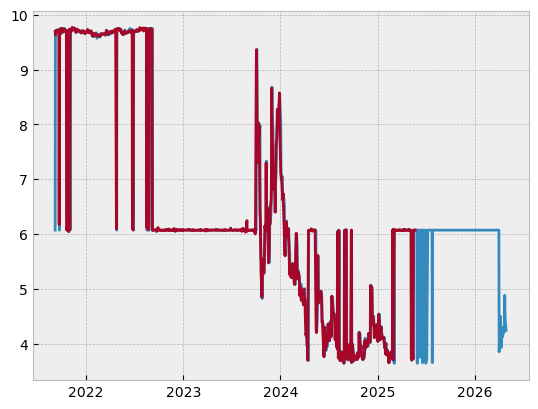

In [208]:
# plotting
train_pred = model.predict(X_train)

plt.plot(df.date, df.open_imputed)
plt.plot(df.date.iloc[0:931], train_pred)

In [ ]:
# computing error 

param_grid={
    'eta': [0.1,0.15,0.001,0.2,0.25,0.3],
    'max_depth': [6,10,20,40,50],
    'tree_method': ['exact'],
    'min_child_weight':[0]

}


grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=param_grid,
    verbose=3,
    return_train_score=True
)


grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END eta=0.1, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.999, test=-0.692) total time=   0.3s
[CV 2/5] END eta=0.1, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=1.000, test=0.855) total time=   0.1s
[CV 3/5] END eta=0.1, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.999, test=0.491) total time=   0.2s
[CV 4/5] END eta=0.1, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.999, test=0.824) total time=   0.2s
[CV 5/5] END eta=0.1, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.999, test=0.713) total time=   0.2s
[CV 1/5] END eta=0.1, max_depth=10, min_child_weight=0, tree_method=exact;, score=(train=1.000, test=-1.087) total time=   0.3s
[CV 2/5] END eta=0.1, max_depth=10, min_child_weight=0, tree_method=exact;, score=(train=1.000, test=0.872) total time=   0.3s
[CV 3/5] END eta=0.1, max_depth=10, min_child_weight

In [ ]:
grid_pred = grid_search.predict(X_test) 


# metrics

